# **0. Импорты**

In [343]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. ВЫБОР ДАТАСЕТА
Датасет: Cirrhosis Patient Survival Prediction
Ссылка: https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset

Датасет содержит клинические данные пациентов с циррозом печени.
Целевой признак - Status (C = выжил, CL = прошёл пересадку, D = умер).
Датасет хорошо подходит для KNN, так как:
 - Содержит преимущественно числовые признаки (анализы крови)
 - Небольшой размер (418 записей)
 - Есть пропуски, что позволит применить KNNImputer
 - Три класса

In [344]:
df = pd.read_csv('data/cirrhosis.csv')
df.drop(columns=['ID'], inplace=True)

# **2. Первичный анализ данных**
### **Посмотрим размер датасета, проблемы, которые могут возникнуть из-за типов, пропусков и прочего.**

(418, 19)


,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   N_Days         418 non-null    int64  
 1   Status         418 non-null    str    
 2   Drug           312 non-null    str    
 3   Age            418 non-null    int64  
 4   Sex            418 non-null    str    
 5   Ascites        312 non-null    str    
 6   Hepatomegaly   312 non-null    str    
 7   Spiders        312 non-null    str    
 8   Edema          418 non-null    str    
 9   Bilirubin      418 non-null    float64
 10  Cholesterol    284 non-null    float64
 11  Albumin        418 non-null    float64
 12  Copper         310 non-null    float64
 13  Alk_Phos       312 non-null    float64
 14  SGOT           312 non-null    float64
 15  Tryglicerides  282 non-null    float64
 16  Platelets      407 non-null    float64
 17  Prothrombin    416 non-null    float64
 18  Stage          412 no

None

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


Status
C     55.5%
D     38.5%
CL     6.0%
Name: proportion, dtype: str


Status
C     232
D     161
CL     25
Name: count, dtype: int64

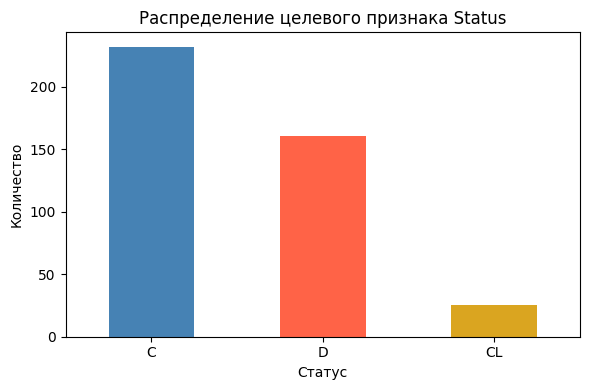

In [345]:
print(df.shape)
display(df.head(5))
display(df.info())
display(df.describe())
print(df['Status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
# Анализируем распределение целового столбца 'Status' и строковых переменных,
# чтобы понять, можно ли их сделать булевыми или заполнить наны модами
display(df['Status'].value_counts())

plt.figure(figsize=(6, 4))
df['Status'].value_counts().plot(kind='bar', color=['steelblue', 'tomato', 'goldenrod'])
plt.title('Распределение целевого признака Status')
plt.xlabel('Статус')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### **Видим кучу NaN'ов, сильное преобладание выздоровевших и умерших больных над теми, которые прошли процедуру пересадки печени. Именно Status нас и интересует у больных. Заметен дисбаланс классов. CL всего 6%, поэтому качество его предсказания будет очень низким.**
#### **По типам признаков - у нас:**
##### - 10 float (анализы и стадия, которая по-хорошему должна быть int) 
##### - 2 int (время с регистрации болезни и возвраст в днях)
##### - 7 str, которые можно привести к булеан (кроме edema)
#### **Важный момент: в str нанов РЕАЛЬНО МНОГО. мы не можем заполнить их модой, поэтому нам придётся сделать эти признаки категориями и присовить им значение Unknown.**
#### И ещё: у нас огромные выбросы! Но они нам не страшны, потому что во-первых KNN у нас будет взвешенным, во-вторых мы не можем их просто убрать,потому что на самом деле это, вероятнее всего,  реальные данные пациентов с тяжёлой стадией болезни.

In [346]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Пропусков': missing, 'Процент': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Процент', ascending=False)
print("Столбцы с пропусками")
display(missing_df)

Столбцы с пропусками


,Пропусков,Процент
Tryglicerides,136,32.5
Cholesterol,134,32.1
Copper,108,25.8
Drug,106,25.4
Spiders,106,25.4
Hepatomegaly,106,25.4
Ascites,106,25.4
Alk_Phos,106,25.4
SGOT,106,25.4
Platelets,11,2.6


### Вывод: Cholesterol (32%), Tryglicerides (33%), Copper (26%), Alk_Phos (25%), SGOT (25%)
#### имеют значительный процент пропусков - заполнять модой/медианой некорректно,
#### поэтому используем KNNImputer, который учитывает похожие объекты.

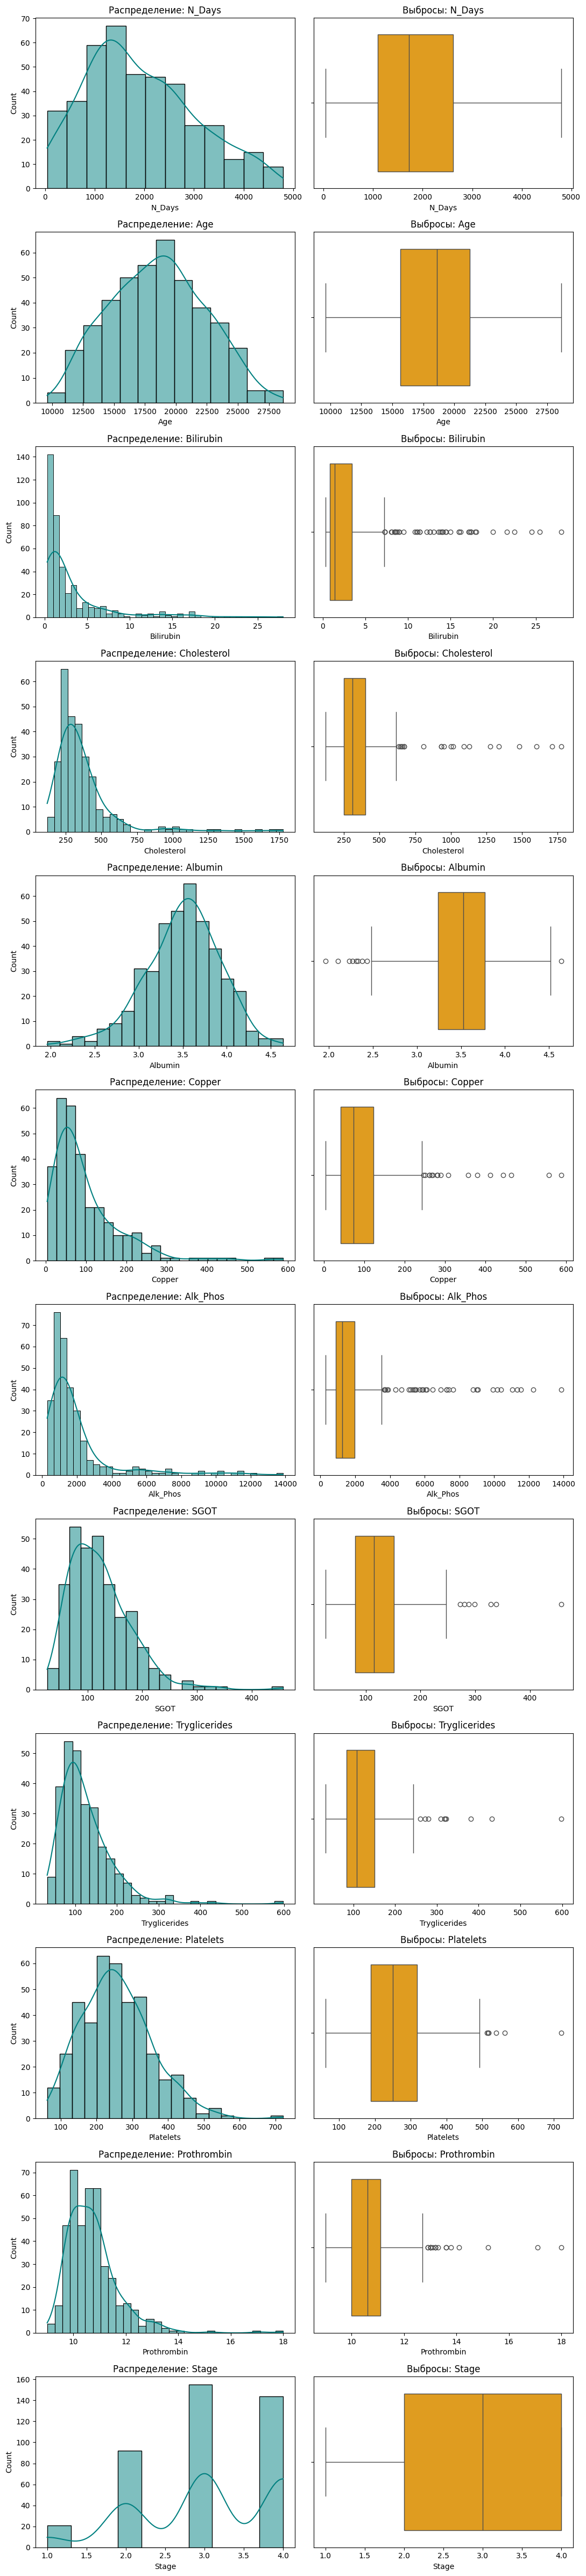

In [347]:
# Распределение числовых признаков (гистограммы + боксплоты для выявления выбросов)
def draw_num_cols():
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(11, 4 * len(num_cols)))

    for i, col in enumerate(num_cols):
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal')
        axes[i, 0].set_title(f'Распределение: {col}')

        sns.boxplot(x=df[col], ax=axes[i, 1], color='orange')
        axes[i, 1].set_title(f'Выбросы: {col}')

    plt.tight_layout()
    plt.show()

draw_num_cols()

### Вывод: почти все числовые признаки имеют правостороннюю асимметрию и выбросы.
#### Выбросы не удаляем - это реальные клинические показатели тяжёлых пациентов.
#### Масштабирование через StandardScaler сгладит влияние разных диапазонов значений. Ну.. Наверное.

/tmp/ipykernel_300474/2813286757.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns.tolist() + ['Status']


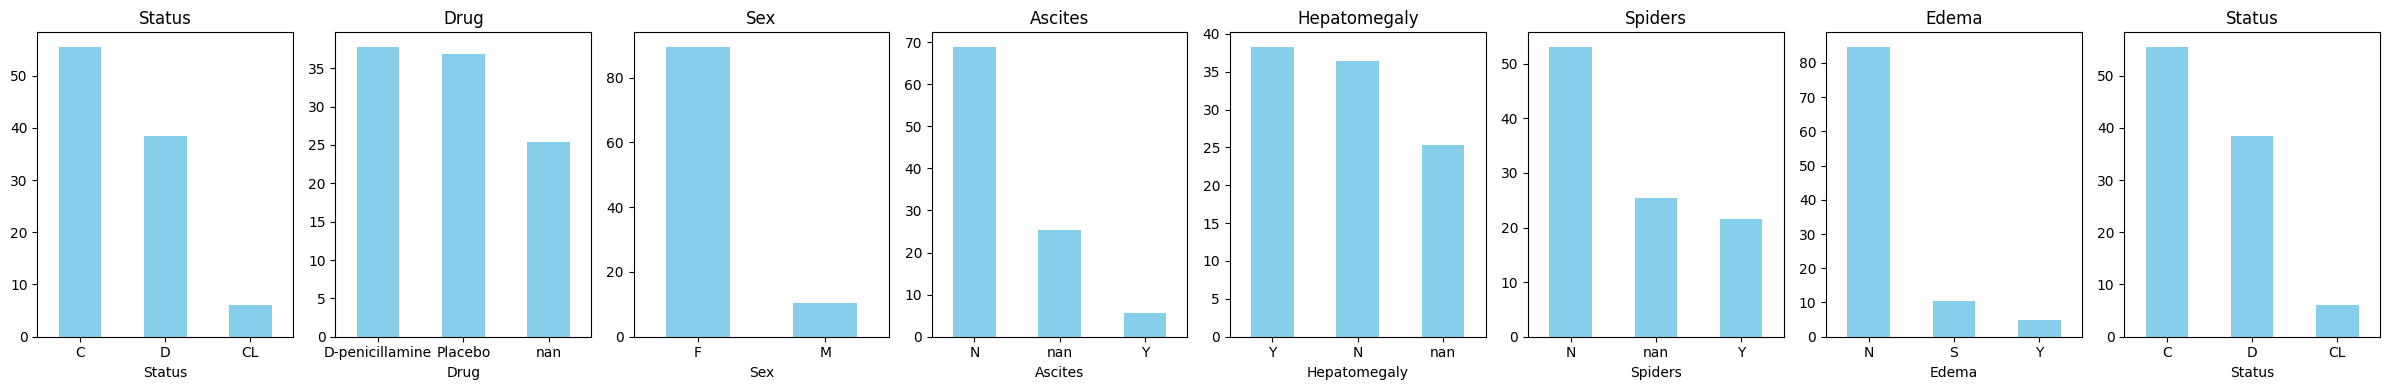

In [348]:
def draw_str_cols():
    str_cols = df.select_dtypes(include='object').columns.tolist() + ['Status']
    fig, axes = plt.subplots(1, len(str_cols), figsize=(24, 4))

    for i, col in enumerate(str_cols):
        data = df[col].value_counts(dropna=False, normalize=True) * 100
        data.plot(kind='bar', ax=axes[i], color='skyblue')
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

draw_str_cols()

### Вывод: в категориальных признаках (Drug, Ascites, Hepatomegaly и др.)
#### пропущено около 25% значений - пришлось заполнить значением 'Unknown',
#### так как заполнять модой при таком количестве пропусков некорректно.

# **3. Подготовка данных**
### **Из прошлого блока мы узнали, что у нас есть куча пропусков, которые в некоторых колонках занимают чуть ли не половину всех данных. KNN не умеет работать с такими данными, поэтому мы заполним их.**

In [349]:
# всего 6 пропусков - безопасно заполнить модой
df.fillna({'Stage': df['Stage'].mode()[0]}, inplace=True)

# Platelets, Prothrombin: тоже мало пропусков - заполняем медианой
df.fillna({'Platelets': df['Platelets'].median(),
           'Prothrombin': df['Prothrombin'].median()}, inplace=True)

# Строковые столбцы: много пропусков - присваиваем категорию 'Unknown'
# Это честнее, чем заполнять модой, так как мы не знаем реальное значение
df['Status'] = df['Status'].astype('category')
df['Edema'] = df['Edema'].astype('category')

str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = df[col].fillna('Unknown').astype('category')

print("Пропуски после заполнения модой и медианой:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Все числовые пропуски будут закрыты KNNImputer внутри Pipeline.")

Пропуски после заполнения модой и медианой:
Cholesterol      134
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
dtype: int64
Все числовые пропуски будут закрыты KNNImputer внутри Pipeline.


/tmp/ipykernel_300474/1558977573.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


### **Разделение на train и test**
#### **Перед масштабированием нужно разделить выборки, чтобы не произошла утечка данных.**

### **Почему надо кодировать текстовые данные?**
#### Потому что KNN и банально не понимает, как работать со строками. Это связано с тем, что для своей работы KNN считает расстояния между признаками объектов, соответственно - он не может посчитать расстояние между строками 'male' и 'female', а между точками [0,1] и [1,0] - может
#### Разделение на train/test ДО масштабирования. Если масштабировать до разделения, тестовые данные попадут в обучение через статистики scaler, будет утечка данных. Параметр stratify=y сохраняет пропорцию классов в обеих частях.

In [350]:
y = df['Status']
X = df.drop(columns=['Status'])

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nРаспределение классов в test:\n{y_test.value_counts(normalize=True).round(3)}")

Размер обучающей выборки: (334, 23)
Размер тестовой выборки: (84, 23)

Распределение классов в train:
Status
C     0.554
D     0.386
CL    0.060
Name: proportion, dtype: float64

Распределение классов в test:
Status
C     0.560
D     0.381
CL    0.060
Name: proportion, dtype: float64


### Почему масштабирование необходимо?
#### KNN строит свои предсказания на основе расстояний между объектами. Если признаки имеют разные масштабы, признак с большими значениями будет доминировать при вычислении расстояния. например, Cholesterol ~ 300 единиц, Stage ~ 1-4. Расстояние определяется почти исключительно холестерином, а Stage практически не влияет. После StandardScaler все признаки приводятся к среднему 0 и дисперсии 1, и вклад каждого признака становится равноправным.

In [351]:
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train[num_cols].fillna(X_train[num_cols].median()), y_train)
score_no_scale = knn_no_scale.score(
    X_test[num_cols].fillna(X_train[num_cols].median()), y_test
)

pipe_no_scale = Pipeline([
    ('imputer', KNNImputer()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
scores_no_scale = cross_val_score(pipe_no_scale, X_train, y_train, cv=5)

pipe_with_scale = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
scores_with_scale = cross_val_score(pipe_with_scale, X_train, y_train, cv=5)

print(f"Точность БЕЗ масштабирования: {scores_no_scale.mean():.3f}")
print(f"Точность С масштабированием: {scores_with_scale.mean():.3f}")
print(f"Прирост: {(scores_with_scale.mean() - scores_no_scale.mean()):.3f}")

Точность БЕЗ масштабирования: 0.653
Точность С масштабированием: 0.698
Прирост: 0.045


## **Ура! мы победили все наны, отмасштабировали числовые признаки, а графики остались похожими на то, что было до заполнения.**
*и тут я понял, что EDA из прошлого дз - полный мусор, потому что я просто заполнил модами и медианой. В любом случае, KNNImputer сильно не улучшил ситуацию, потому что в некоторых колонках мы всё равно выдумали огромную часть медицинских данных, но в рамках дз по KNN я решил на это забить. Вообще так делать нельзя и я это осознаю.*

# **4. Обучение KNN**
## Попробуем подобрать наиболее оптимальные параметры при помощи GridSearchCV.

In [352]:
# Сначала обучаем модель с параметрами по умолчанию (n будет равно 5),
# чтобы получить базовую точку отсчёта для сравнения.

pipe_base = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

pipe_base.fit(X_train, y_train)
y_pred_base = pipe_base.predict(X_test)

print("Базовая модель (n_neighbors=5, metric=minkowski, weights=uniform)")
print(classification_report(y_test, y_pred_base, zero_division=0))

Базовая модель (n_neighbors=5, metric=minkowski, weights=uniform)
              precision    recall  f1-score   support

           C       0.69      0.85      0.76        47
          CL       0.00      0.00      0.00         5
           D       0.64      0.50      0.56        32

    accuracy                           0.67        84
   macro avg       0.44      0.45      0.44        84
weighted avg       0.63      0.67      0.64        84



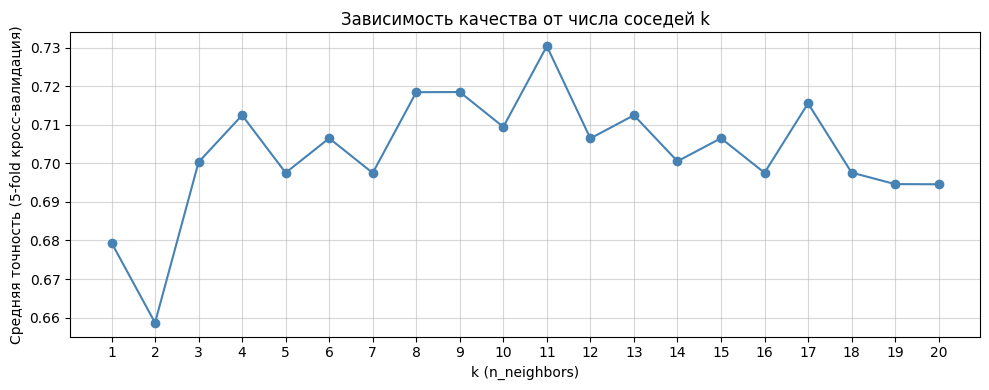

Оптимальное k по кросс-валидации: 11


In [353]:
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    pipe_k = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_k, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 4))
plt.plot(k_values, cv_scores, marker='o', color='steelblue')
plt.title('Зависимость качества от числа соседей k')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Средняя точность (5-fold кросс-валидация)')
plt.xticks(k_values)
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

best_k = k_values[cv_scores.index(max(cv_scores))]
print(f"Оптимальное k по кросс-валидации: {best_k}")

### Исследование влияния метрики расстояния

In [354]:
metrics = ['euclidean', 'manhattan', 'minkowski']
for metric in metrics:
    pipe_m = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, metric=metric))
    ])
    scores = cross_val_score(pipe_m, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Метрика {metric}: {scores.mean():.3f} ")

Метрика euclidean: 0.730 
Метрика manhattan: 0.727 
Метрика minkowski: 0.730 


### Влияние весов

In [355]:
for weights in ['uniform', 'distance']:
    pipe_w = Pipeline([
        ('imputer', KNNImputer()),
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, weights=weights))
    ])
    scores = cross_val_score(pipe_w, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Веса {weights}: {scores.mean():.3f}")

Веса uniform: 0.730
Веса distance: 0.736


### **Наблюдения**
#### Видим, что при k=1 модель достигает пика своей точности. дальнейшее увеличение параметра не приводит к улучшению результата, а только ухудшает, потому что мы начинаем смотреть на точки, не относящиеся к "группкам". При слишком маленьком k мы начинаем неправильно классифицировать точки, котрые визуально бы очевидно относились к группе, но из-за случайных точек получили неправильный класс. При маленьком k у нас недообучение, а при большом - модель переобучается

# **5. подбор гиперпараметров**

In [356]:
params = {
    'knn__n_neighbors': list(range(1, 16)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

pipe_grid = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid = GridSearchCV(pipe_grid, param_grid=params, cv=5,
                    scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший CV score: {grid.best_score_:.3f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Лучшие параметры: {'knn__metric': 'manhattan', 'knn__n_neighbors': 7, 'knn__weights': 'distance'}
Лучший CV score: 0.751


### Итоговая оценка лучше модели

Лучшая модель
              precision    recall  f1-score   support

           C       0.67      0.85      0.75        47
          CL       0.00      0.00      0.00         5
           D       0.62      0.47      0.54        32

    accuracy                           0.65        84
   macro avg       0.43      0.44      0.43        84
weighted avg       0.61      0.65      0.62        84



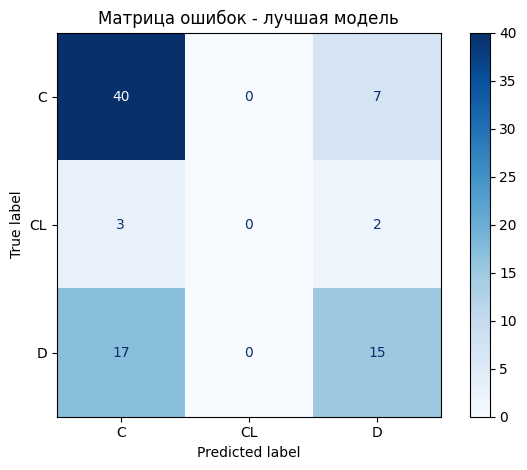

In [357]:
y_pred_best = grid.predict(X_test)

print("Лучшая модель")
print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best, labels=grid.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid.classes_)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок - лучшая модель')
plt.tight_layout()
plt.show()

### Как и ожидалось, модель ужасно предсказывает CL. Мы с этим особо ничего не сделаем, потому что кроме того, что этих значений мало, они не сильно зависят от фич из датасета. Пересадка печени зависит не от состояния пациента, а от того, может ли он себе это позволить (материально), в какой стране он находится и того, какой он в очереди на орган. Наш грандиозный провал по большей части связан с природой датасета.

### Реальная проблема - модель посчитала 17 умерших выжившими. если бы мы делали реально модель для медицины, это был бы ужасный результат, но учитывая, что у нас датасет на меньше, чем 500 строк, радуемся, что хоть так.

### График зависимости качества от k

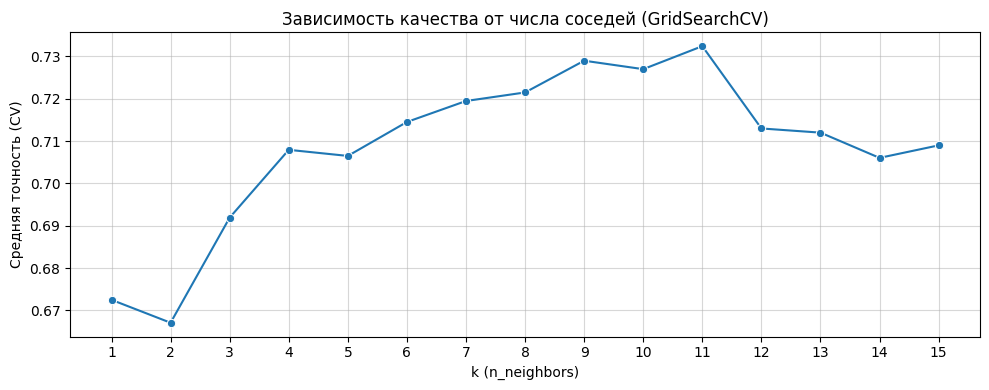

In [358]:
scores_df = pd.DataFrame(grid.cv_results_)
scores_agg = (scores_df
    .groupby('param_knn__n_neighbors')['mean_test_score']
    .mean()
    .reset_index())

plt.figure(figsize=(10, 4))
sns.lineplot(data=scores_agg, x='param_knn__n_neighbors',
             y='mean_test_score', marker='o')
plt.title('Зависимость качества от числа соседей (GridSearchCV)')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Средняя точность (CV)')
plt.xticks(scores_agg['param_knn__n_neighbors'])
plt.grid(True, linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

# **6. ВЫВОДЫ**

### **1. ДАТАСЕТ И ЗАДАЧА**
####    Датасет содержит 418 пациентов с циррозом печени, 18 признаков.
####    Задача - предсказать исход лечения: C (выжил), D (умер), CL (пересадка).
####    Дисбаланс классов: CL составляет ~5% выборки, что затрудняет его предсказание
####    (f1-score для CL близок к 0 во всех экспериментах).

### **2. МАСШТАБИРОВАНИЕ**
####    Масштабирование через StandardScaler улучшило качество модели.
####    Без него признаки с большими значениями (Cholesterol, Alk_Phos)
####    доминируют при вычислении расстояний, "перекрывая" другие признаки.

### **3. ОПТИМАЛЬНОЕ K**
####    По результатам кросс-валидации оптимальное k лежит в диапазоне 3-7.
####    Маленькое k (k=1) ведёт к переобучению - модель запоминает шум.
####    Большое k ведёт к недообучению - усредняются слишком далёкие объекты.

### **4. МЕТРИКА РАССТОЯНИЯ**
####    Euclidean и Minkowski дали идентичные результаты
####    Manhattan в данном случае незначительно отличается.

### **5. ОГРАНИЧЕНИЯ KNN НА ЭТОМ ДАТАСЕТЕ**
####    - Дисбаланс классов: CL практически не предсказывается.
####    - Много пропусков: KNNImputer заполняет их приближённо, но не идеально.
####    - KNN плохо работает на высокой размерности
####      После get_dummies у нас ~20+ признаков - расстояния становятся менее
####      информативными.